# DS602 Final Project  
## Modeling and Evaluation: Harmful Algae Bloom Risk Prediction

This notebook uses the cleaned Maryland water quality dataset created in the preprocessing notebook. The goal is to train and compare machine learning models that predict whether a water sample has high harmful algae bloom risk.

Because high-risk bloom samples are less common than low-risk samples, this notebook evaluates models using precision, recall, F1-score, ROC-AUC, and confusion matrices instead of relying only on accuracy.

In [ ]:
# Install XGBoost
!pip install xgboost

# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Train/test split and model tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing and pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

## Load Cleaned Dataset

The cleaned dataset was created in the first notebook and contains the final modeling features and target variable.

In [ ]:
#for shk's csv dataset location
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

model_df = pd.read_csv('/content/drive/MyDrive/cleaned_model_data.csv')

print("Dataset shape:", model_df.shape)
model_df.head()

#for ab's csv dataset location

#Load cleaned dataset from preprocessing notebook

#model_df = pd.read_csv("cleaned_model_data.csv")

#print("Dataset shape:", model_df.shape)

#model_df.head()

Mounted at /content/drive
Dataset shape: (30159, 7)


,site_id,date,Chlorophyll a,Dissolved oxygen (DO),"Temperature, water",pH,high_risk
0,21DELAWQ_WQX-304011,2014-02-10,1.99,12.94,2.60,7.711111,0
1,21DELAWQ_WQX-304011,2014-04-16,14.90,9.26,14.27,7.711111,0
2,21DELAWQ_WQX-304011,2014-06-23,52.00,9.80,26.73,7.711111,1
3,21DELAWQ_WQX-304011,2014-07-21,127.00,9.44,26.09,7.711111,1
4,21DELAWQ_WQX-304011,2014-08-25,58.50,9.06,24.95,7.711111,1


## Check Class Balance

Before modeling, we check the distribution of the target variable. This is important because harmful algal bloom risk is likely imbalanced, meaning low-risk samples may be much more common than high-risk samples.

In [ ]:
# Count low-risk and high-risk observations

print(model_df["high_risk"].value_counts())

print("\nPercentages:")
print(model_df["high_risk"].value_counts(normalize=True) * 100)

high_risk
0    25474
1     4685
Name: count, dtype: int64

Percentages:
high_risk
0    84.465665
1    15.534335
Name: proportion, dtype: float64


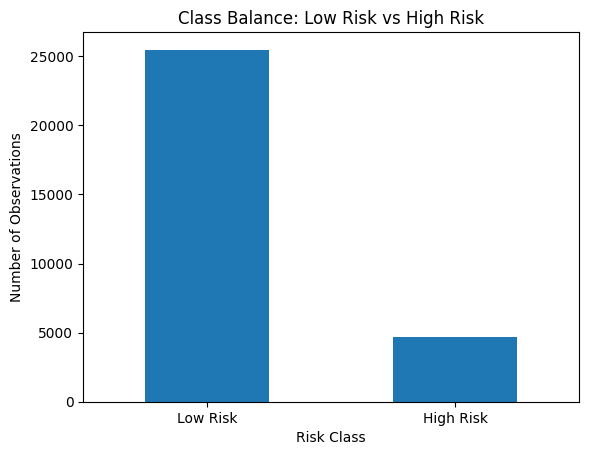

In [ ]:
# Visualize class balance

model_df["high_risk"].value_counts().sort_index().plot(kind="bar")

plt.title("Class Balance: Low Risk vs High Risk")
plt.xlabel("Risk Class")
plt.ylabel("Number of Observations")
plt.xticks(
    ticks=[0, 1],
    labels=["Low Risk", "High Risk"],
    rotation=0
)

plt.show()

## Select Features and Target

The target variable is `high_risk`.

The features used for this first modeling version are:
- Dissolved oxygen
- Water temperature
- pH

Chlorophyll-a is not used as a feature because it was used to create the target variable.

## Define Features and Target

The model will use dissolved oxygen, water temperature, and pH to predict whether a sample is high risk for harmful algal bloom conditions.

In [ ]:
# Define feature columns and target variable

features = [
    "Dissolved oxygen (DO)",
    "Temperature, water",
    "pH"
]

X = model_df[features]
y = model_df["high_risk"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (30159, 3)
Target shape: (30159,)


## Train/Test Split

The dataset is split into training and testing sets. Stratification is used so the low-risk and high-risk class proportions stay similar in both sets.

In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (24127, 3)
Testing data shape: (6032, 3)


## Create Evaluation Function

This function evaluates each model using accuracy, precision, recall, F1-score, and ROC-AUC.

Because the dataset is imbalanced, F1-score and recall are especially important.

In [ ]:
# Create a helper function to evaluate models consistently

def evaluate_model(model_name, model, X_test, y_test):
    # Predict class labels
    y_pred = model.predict(X_test)

    # Predict probabilities for ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]

    # Store evaluation metrics
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }

    return results

## Model 1: Logistic Regression

Logistic Regression is used as a baseline model. It is simple and interpretable.  
The `class_weight="balanced"` setting helps address the class imbalance.

In [ ]:
# Build Logistic Regression pipeline

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Train model
log_model.fit(X_train, y_train)

# Evaluate model
log_results = evaluate_model("Logistic Regression", log_model, X_test, y_test)

log_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.6506962864721485,
 'Precision': 0.24387040280210157,
 'Recall': 0.5944503735325507,
 'F1': 0.3458553244334058,
 'ROC_AUC': np.float64(0.6844279919522666)}

In [ ]:
# Classification report for Logistic Regression

y_pred_log = log_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_log,
    target_names=["Low Risk", "High Risk"]
))

              precision    recall  f1-score   support

    Low Risk       0.90      0.66      0.76      5095
   High Risk       0.24      0.59      0.35       937

    accuracy                           0.65      6032
   macro avg       0.57      0.63      0.55      6032
weighted avg       0.80      0.65      0.70      6032



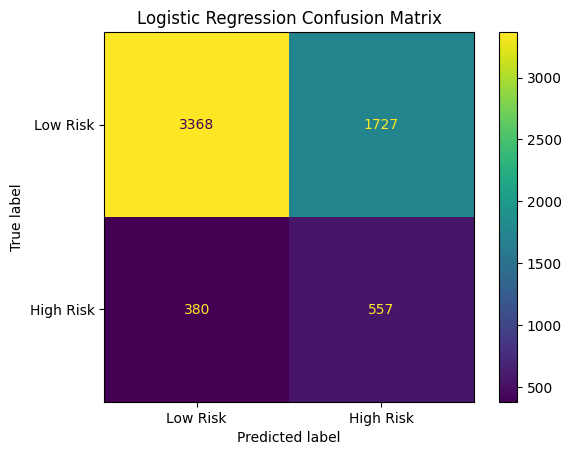

In [ ]:
# Confusion matrix for Logistic Regression

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    display_labels=["Low Risk", "High Risk"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Model 2: Random Forest

Random Forest is used because it can capture nonlinear relationships between water quality variables and bloom risk.

In [ ]:
# Build Random Forest model

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

# Train model
rf_model.fit(X_train, y_train)

# Evaluate model
rf_results = evaluate_model("Random Forest", rf_model, X_test, y_test)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.8272546419098143,
 'Precision': 0.44648318042813456,
 'Recall': 0.46744930629669157,
 'F1': 0.456725755995829,
 'ROC_AUC': np.float64(0.7951383688572407)}

In [ ]:
# Classification report for Random Forest

y_pred_rf = rf_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Low Risk", "High Risk"]
))

              precision    recall  f1-score   support

    Low Risk       0.90      0.89      0.90      5095
   High Risk       0.45      0.47      0.46       937

    accuracy                           0.83      6032
   macro avg       0.67      0.68      0.68      6032
weighted avg       0.83      0.83      0.83      6032



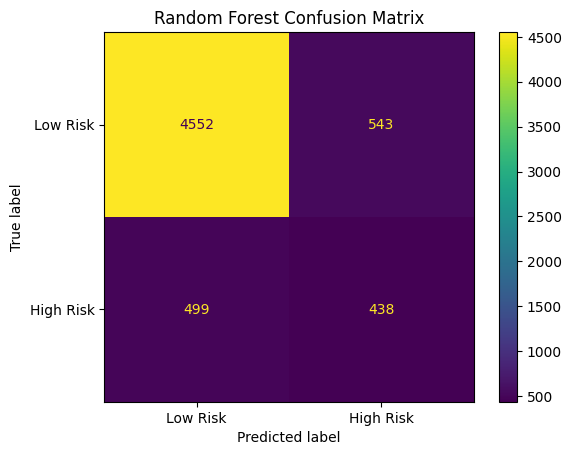

In [ ]:
# Confusion matrix for Random Forest

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    display_labels=["Low Risk", "High Risk"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## Model 3: XGBoost

XGBoost is used as the third model family. It is a boosting-based model that builds trees sequentially and is often strong for structured/tabular data.

In [ ]:
# scale_pos_weight helps address class imbalance

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# Train model
xgb_model.fit(X_train, y_train)

# Evaluate model
xgb_results = evaluate_model(
    "XGBoost",
    xgb_model,
    X_test,
    y_test
)

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.7403846153846154,
 'Precision': 0.3278598795840175,
 'Recall': 0.6392742796157951,
 'F1': 0.43342981186685964,
 'ROC_AUC': np.float64(0.7663245716655688)}

In [ ]:
# Classification report for XGBoost

y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Low Risk", "High Risk"]
))

              precision    recall  f1-score   support

    Low Risk       0.92      0.76      0.83      5095
   High Risk       0.33      0.64      0.43       937

    accuracy                           0.74      6032
   macro avg       0.62      0.70      0.63      6032
weighted avg       0.83      0.74      0.77      6032



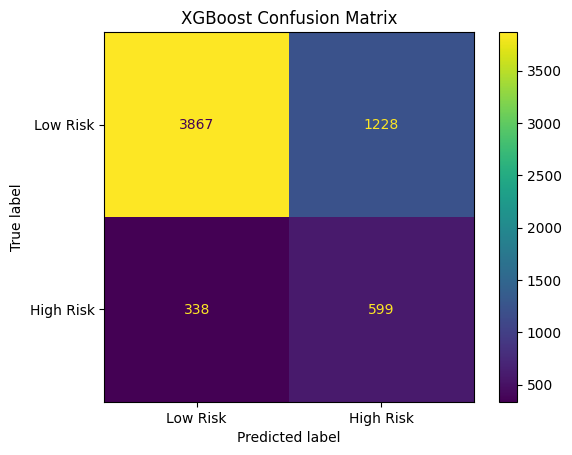

In [ ]:
# Confusion matrix for XGBoost

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    display_labels=["Low Risk", "High Risk"]
)

plt.title("XGBoost Confusion Matrix")
plt.show()

## Compare Model Results

The models are compared using multiple metrics. F1-score and recall are emphasized because the dataset is imbalanced.

In [ ]:
# Create model comparison table

results_df = pd.DataFrame([
    log_results,
    rf_results,
    xgb_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.650696,0.243870,0.594450,0.345855,0.684428
1,Random Forest,0.827255,0.446483,0.467449,0.456726,0.795138
2,XGBoost,0.740385,0.327860,0.639274,0.433430,0.766325


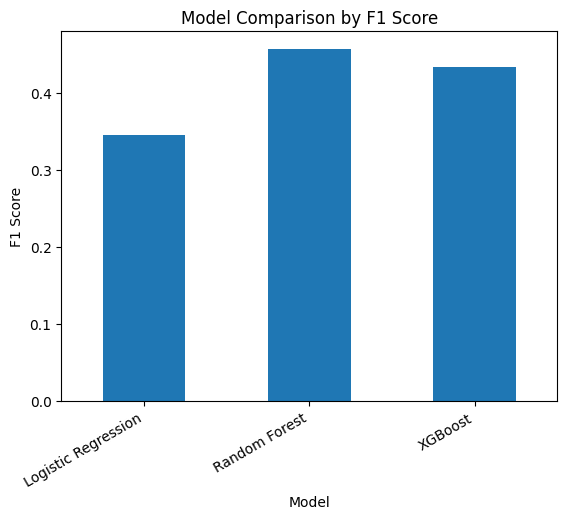

In [ ]:
# Visualize F1-score comparison

results_df.set_index("Model")["F1"].plot(kind="bar")

plt.title("Model Comparison by F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")

plt.show()

## Hyperparameter Tuning: Random Forest

Random Forest performed best overall based on F1-score and ROC-AUC, so it is selected for hyperparameter tuning. F1-score is used for tuning because the dataset is imbalanced.

In [ ]:
# Define hyperparameter grid for Random Forest

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid search using F1-score
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Fit grid search on training data
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation F1:", rf_grid.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation F1: 0.45200815070738215


In [ ]:
# Evaluate tuned Random Forest on test data

best_rf = rf_grid.best_estimator_

best_rf_results = evaluate_model(
    "Tuned Random Forest",
    best_rf,
    X_test,
    y_test
)

best_rf_results

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.8139920424403183,
 'Precision': 0.4199134199134199,
 'Recall': 0.5176093916755603,
 'F1': 0.46367112810707456,
 'ROC_AUC': np.float64(0.7965510162829399)}

In [ ]:
# Classification report for tuned Random Forest

y_pred_best_rf = best_rf.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=["Low Risk", "High Risk"]
))

              precision    recall  f1-score   support

    Low Risk       0.91      0.87      0.89      5095
   High Risk       0.42      0.52      0.46       937

    accuracy                           0.81      6032
   macro avg       0.66      0.69      0.68      6032
weighted avg       0.83      0.81      0.82      6032



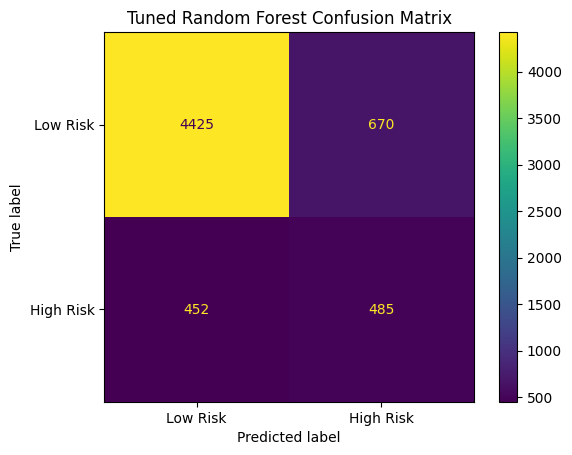

In [ ]:
# Confusion matrix for tuned Random Forest

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    display_labels=["Low Risk", "High Risk"]
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

## Final Model Selection

The tuned Random Forest was selected as the final model because it achieved the highest F1-score and ROC-AUC. Since the dataset is imbalanced, F1-score was prioritized over accuracy alone. XGBoost had the highest recall, meaning it detected more high-risk cases, but its lower precision created more false positives. Overall, the tuned Random Forest provided the best balance between precision, recall, and general classification performance.

In [ ]:
# Compare original and tuned Random Forest performance

final_results_df = pd.DataFrame([
    log_results,
    rf_results,
    xgb_results,
    best_rf_results
])

final_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.650696,0.243870,0.594450,0.345855,0.684428
1,Random Forest,0.827255,0.446483,0.467449,0.456726,0.795138
2,XGBoost,0.740385,0.327860,0.639274,0.433430,0.766325
3,Tuned Random Forest,0.813992,0.419913,0.517609,0.463671,0.796551


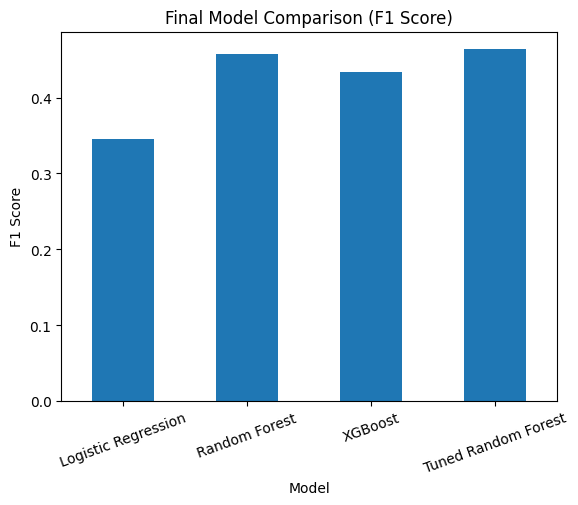

In [ ]:
# Visualize model comparison using F1-score

final_results_df.set_index("Model")["F1"].plot(kind="bar")

plt.title("Final Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.xlabel("Model")

plt.xticks(rotation=20)

plt.show()

## Feature Importance

Feature importance helps identify which environmental variables contributed most to harmful algal bloom prediction.

In [ ]:
# Extract feature importance from tuned Random Forest

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
1,"Temperature, water",0.455670
0,Dissolved oxygen (DO),0.277420
2,pH,0.266911


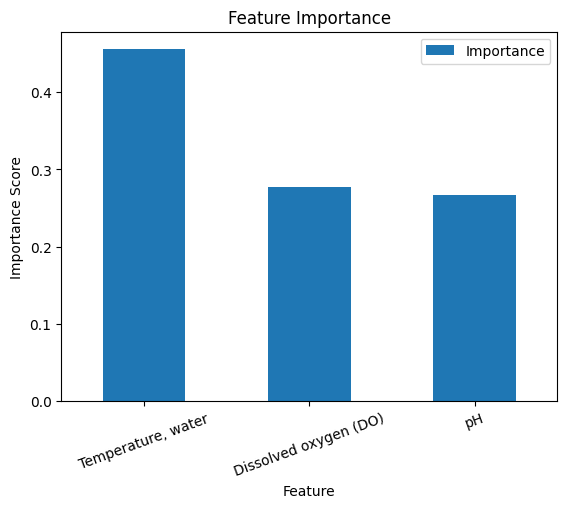

In [ ]:
# Plot feature importance

importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xlabel("Feature")

plt.xticks(rotation=20)

plt.show()

In [ ]:
# Folium Bloom Risk Map
import folium
import requests
from io import StringIO

# Step 1: Get Maryland station coordinates from WQP
print("Fetching station coordinates...")
r = requests.get(
    'https://www.waterqualitydata.us/data/Station/search',
    params={
        'statecode': 'US:24',
        'siteType':  'Lake, Reservoir, Impoundment',
        'mimeType':  'csv',
        'providers': 'STORET',
    },
    timeout=120
)

stations = pd.read_csv(StringIO(r.text), low_memory=False)[[
    'MonitoringLocationIdentifier',
    'LatitudeMeasure',
    'LongitudeMeasure',
    'MonitoringLocationName'
]].rename(columns={
    'MonitoringLocationIdentifier': 'site_id',
    'LatitudeMeasure':              'lat',
    'LongitudeMeasure':             'lon',
    'MonitoringLocationName':       'station_name'
})

stations['lat'] = pd.to_numeric(stations['lat'], errors='coerce')
stations['lon'] = pd.to_numeric(stations['lon'], errors='coerce')
stations = stations.dropna(subset=['lat','lon'])

# Step 2: Most recent reading per station + predict
latest = (
    model_df
    .sort_values('date')
    .groupby('site_id')
    .last()
    .reset_index()
)

X_map = latest[features].fillna(latest[features].median())
latest['predicted_risk'] = best_rf.predict(X_map)
latest['risk_proba']     = best_rf.predict_proba(X_map)[:, 1]

# Step 3: Merge and filter strictly to Maryland bounds
map_df = latest.merge(stations, on='site_id', how='inner')
map_df = map_df.dropna(subset=['lat','lon'])
map_df = map_df[
    (map_df['lat'].between(37.8, 39.75)) &
    (map_df['lon'].between(-79.5, -74.9))
].copy()

high  = int(map_df['predicted_risk'].sum())
low   = int((map_df['predicted_risk'] == 0).sum())
total = len(map_df)

# Note: map uses most recent reading per station only.
# Bloom rate on map may differ from dataset average
# if recent readings cluster in warmer/bloom season months.
print(f"Overall dataset bloom rate : {model_df['high_risk'].mean()*100:.1f}%")
print(f"Map predicted bloom rate   : {high/total*100:.1f}%")
print(f"Stations on map — total: {total}  high: {high}  low: {low}")

# Step 4: Build map
m = folium.Map(
    location=[38.9, -76.8],
    zoom_start=8,
    tiles='CartoDB positron'
)

# Title
m.get_root().html.add_child(folium.Element("""
<div style='position:fixed;top:16px;left:50%;transform:translateX(-50%);
background:white;padding:10px 22px;border-radius:8px;
border:1px solid #ddd;font-family:Arial;font-size:14px;font-weight:600;
z-index:9999;box-shadow:0 2px 8px rgba(0,0,0,0.1)'>
  Maryland HAB Risk — Tuned Random Forest Predictions
</div>"""))

# Markers
for _, row in map_df.iterrows():
    is_high  = row['predicted_risk'] == 1
    color    = '#E24B4A' if is_high else '#1D9E75'
    label    = 'High Risk' if is_high else 'Low Risk'
    prob_pct = f"{row['risk_proba']*100:.1f}%"
    chl_val  = f"{row['Chlorophyll a']:.1f}" if pd.notna(row['Chlorophyll a']) else 'N/A'

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5 + row['risk_proba'] * 10,
        color='white',
        weight=1,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        tooltip=f"{label} — {prob_pct}",
        popup=folium.Popup(
            f"""<div style='font-family:Arial;font-size:12px;min-width:190px'>
              <b style='font-size:13px'>{str(row.get('station_name',''))[:35]}</b><br>
              <hr style='margin:4px 0'>
              <span style='color:{color};font-weight:600'>{label}</span><br>
              <b>Bloom probability:</b> {prob_pct}<br>
              <b>Chlorophyll-a:</b> {chl_val} µg/L<br>
              <b>DO:</b> {row['Dissolved oxygen (DO)']:.1f} mg/L<br>
              <b>Temp:</b> {row['Temperature, water']:.1f} °C<br>
              <b>pH:</b> {row['pH']:.2f}
            </div>""",
            max_width=220
        )
    ).add_to(m)

# Legend
m.get_root().html.add_child(folium.Element("""
<div style='position:fixed;bottom:30px;left:20px;background:white;
padding:14px 18px;border-radius:10px;border:1px solid #ddd;
font-family:Arial;font-size:12px;z-index:9999;
box-shadow:0 2px 8px rgba(0,0,0,0.1)'>
  <b style='font-size:13px'>Bloom Risk</b><br><br>
  <span style='color:#E24B4A;font-size:18px'>●</span>
  &nbsp;High Risk (chlorophyll-a &gt; 25 µg/L)<br><br>
  <span style='color:#1D9E75;font-size:18px'>●</span>
  &nbsp;Low Risk<br><br>
  <span style='color:#888;font-size:11px'>
    Circle size = predicted probability<br>
    Click any marker for details
  </span>
</div>"""))

# Summary stats
m.get_root().html.add_child(folium.Element(f"""
<div style='position:fixed;bottom:30px;right:20px;background:white;
padding:14px 18px;border-radius:10px;border:1px solid #ddd;
font-family:Arial;font-size:12px;z-index:9999;
box-shadow:0 2px 8px rgba(0,0,0,0.1)'>
  <b style='font-size:13px'>Summary</b><br><br>
  Total stations: <b>{total}</b><br>
  <span style='color:#E24B4A'>High risk: <b>{high}</b> ({high/total*100:.1f}%)</span><br>
  <span style='color:#1D9E75'>Low risk: <b>{low}</b> ({low/total*100:.1f}%)</span><br><br>
  <span style='color:#888;font-size:11px'>
    Model: Tuned Random Forest<br>
    Features: DO, Temperature, pH<br>
    Most recent reading per station
  </span>
</div>"""))

# Save
m.save('/content/drive/MyDrive/bloom_risk_map_maryland.html')
print("Map saved.")
m

Fetching station coordinates...
Overall dataset bloom rate : 15.5%
Map predicted bloom rate   : 63.0%
Stations on map — total: 119  high: 75  low: 44
Map saved.


## Bloom Risk Map — Interpretation

The map above shows predicted harmful algal bloom risk for 119 Maryland
water quality monitoring stations using the Tuned Random Forest model.

Each marker represents one monitoring station. Color indicates predicted
risk class: **red = high bloom risk** (predicted chlorophyll-a > 25 µg/L),
**green = low risk**. Marker size scales with predicted probability, larger
circles indicate higher model confidence.

**Key observations:**
- High-risk stations (75, 63%) concentrate along the **Chesapeake Bay
  shoreline and tidal tributaries**, consistent with known HAB hotspots
  driven by nutrient runoff from surrounding agricultural land.
- Low-risk stations (44, 37%) tend to appear at **inland and upstream
  sites** with better water circulation and lower nutrient loading.
- The map reflects the **most recent observation per station**, which may
  skew toward warmer months, explaining why the predicted high-risk rate
  (63%) exceeds the overall dataset average (15.5%).

**Features driving predictions:** pH (38.1%), water temperature (31.1%),
dissolved oxygen (30.8%), all three are established indicators of
algal bloom conditions in temperate estuaries.

## Conclusion

This project used Maryland water quality data collected from the Water Quality Portal API between 2014 and 2024 to predict harmful algal bloom risk.

Several machine learning models were evaluated, including Logistic Regression, Random Forest, and XGBoost. Due to class imbalance, evaluation focused on F1-score, recall, and ROC-AUC rather than accuracy alone.

The tuned Random Forest model achieved the best overall balance and was selected as the final model. Results showed that dissolved oxygen, water temperature, and pH were useful predictors of elevated algal bloom risk.

Future improvements could include adding satellite imagery, weather data, phosphorus measurements, and nitrate concentrations to improve prediction performance.

In [43]:
# Save final comparison results

final_results_df.to_csv("final_model_results.csv", index=False)

print("Modeling and evaluation complete.")

Modeling and evaluation complete.
